# Batch Size Dynamics - Real-Time Tracking Notebook
This notebook tracks the relationship between distillation batch size and cross-model accuracy.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ci_95(arr):
    if len(arr) < 2:
        return 0.0
    return 1.96 * np.std(arr) / np.sqrt(len(arr))

cache_file = '../experiments/cache/batch_size_dynamics.json'
if os.path.exists(cache_file):
    with open(cache_file, 'r') as f:
        data = json.load(f)
else:
    print('Cache file not found yet.')
    data = {}

In [2]:
if data:
    records = []
    for key, val in data.items():
        if key in ['Reference', 'Teacher']:
            continue
        bs = int(key)
        for metric, arr in val.items():
            mean_val = np.mean(arr)
            err_val = ci_95(arr)
            records.append({'Batch Size': bs, 'Metric': metric, 'Mean': mean_val, 'Error': err_val})
    df = pd.DataFrame(records)
    display(df)

,Batch Size,Metric,Mean,Error
0,16,Student (aux. only),0.68922,0.067849
1,16,Student (all logits),0.93866,0.001490
2,16,Cross-model (aux. only),0.23003,0.146434
3,16,Cross-model (all logits),0.87581,0.024435
4,64,Student (aux. only),0.79937,0.023742
5,64,Student (all logits),0.94120,0.001148
6,64,Cross-model (aux. only),0.16749,0.129015
7,64,Cross-model (all logits),0.82722,0.034604
8,256,Student (aux. only),0.71310,0.046886
9,256,Student (all logits),0.93756,0.001632


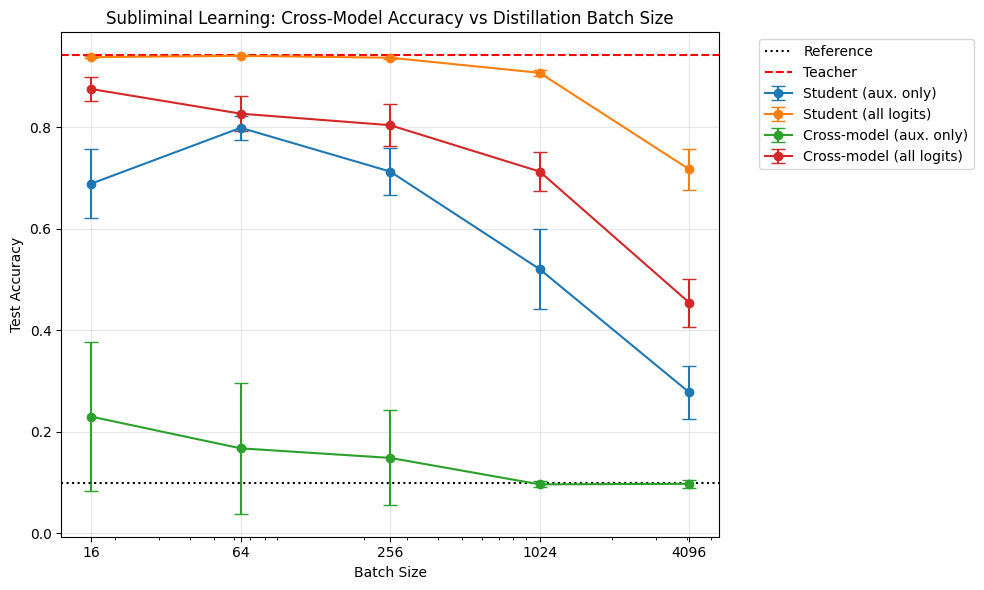

In [3]:
if data and 'df' in locals() and not df.empty:
    plt.figure(figsize=(10, 6))
    for metric in df['Metric'].unique():
        subset = df[df['Metric'] == metric].sort_values('Batch Size')
        plt.errorbar(subset['Batch Size'], subset['Mean'], yerr=subset['Error'], label=metric, marker='o', capsize=5)
    
    if 'Reference' in data:
        plt.axhline(np.mean(data['Reference']), ls=':', c='black', label='Reference')
    if 'Teacher' in data:
        plt.axhline(np.mean(data['Teacher']), ls='--', c='red', label='Teacher')
        
    plt.xscale('log')
    plt.xticks([16, 64, 256, 1024, 4096], ['16', '64', '256', '1024', '4096'])
    plt.xlabel('Batch Size')
    plt.ylabel('Test Accuracy')
    plt.title('Subliminal Learning: Cross-Model Accuracy vs Distillation Batch Size')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()